In [4]:
from autoenkoop import *
import torch
import numpy as np
import pandas as pd
import os
from matplotlib.colors import Normalize

In [5]:
datafile = np.load(os.path.join("..", "data", "T1492_x1151_y1_z127_c2.npz"))
data = datafile['timeseries']
print(data.shape)

(vx_min, vx_max), (vz_min, vz_max) = get_min_max(data)
norm_x = Normalize(vmin=vx_min, vmax=vx_max)
norm_z = Normalize(vmin=vz_min, vmax=vz_max)

(1493, 1151, 127, 2)


In [6]:
mean_removed_data = data - np.mean(data, axis=0)
dataset = TOffsetDataset(mean_removed_data, t_offset=1)

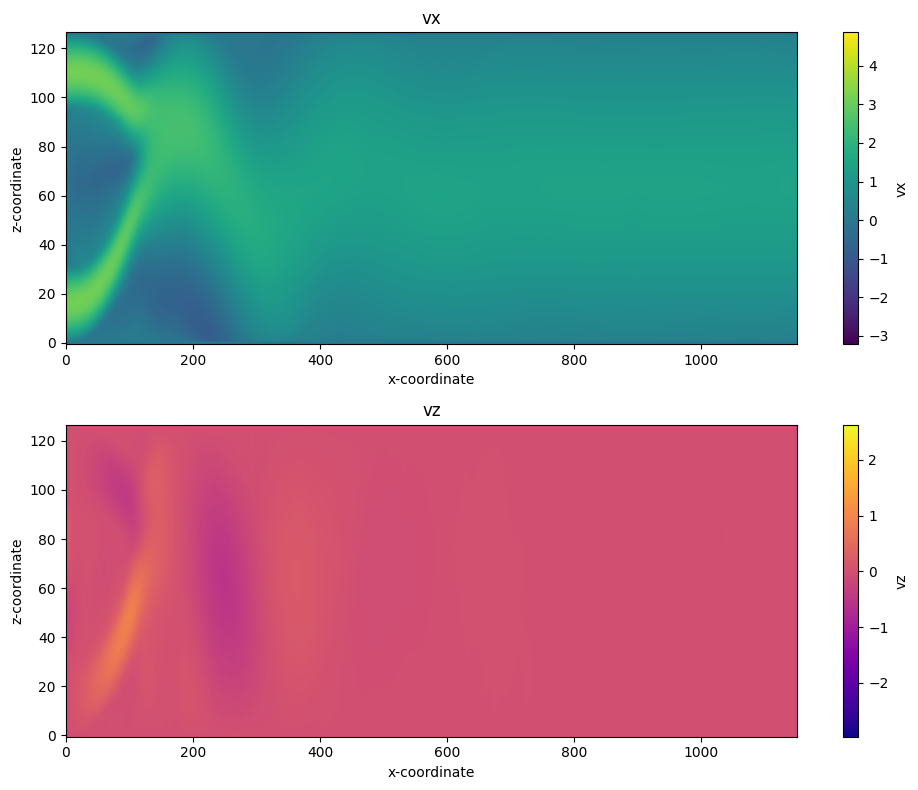

In [7]:
vx_tempmean = np.mean(data, axis=0)[...,0]
vz_tempmean = np.mean(data, axis=0)[...,1]
plot_vx_vz(vx_tempmean, vz_tempmean, norm_x, norm_z)

In [ ]:
results_path = os.path.join("..", "results")
#run_path = os.path.join(results_path, "koopman_autoencoder_classic", "lambda_001")
run_path = os.path.join(results_path, "koopman_autoencoder_exponential_contrast", "L128_a20_lcon10_100_lr_0.0005")

In [9]:
LATENT_DIMENSION = 128
DEVICE = "cpu"#"cuda" if torch.cuda.is_available() else "cpu"
kae_model = ConvAutoencoder(latent_dim=LATENT_DIMENSION).to(DEVICE)

In [10]:
kae_model.load_state_dict(torch.load(os.path.join(run_path, "model.pt"), map_location=DEVICE))

RuntimeError: Error(s) in loading state_dict for ConvAutoencoder:
	Missing key(s) in state_dict: "decoder.5.weight", "decoder.5.bias", "decoder.7.running_mean", "decoder.7.running_var", "decoder.8.weight", "decoder.8.bias", "decoder.10.running_mean", "decoder.10.running_var", "decoder.11.weight", "decoder.11.bias", "decoder.13.running_mean", "decoder.13.running_var", "decoder.14.weight", "decoder.14.bias". 
	Unexpected key(s) in state_dict: "decoder.4.weight", "decoder.4.bias", "decoder.6.weight", "decoder.6.bias", "decoder.6.running_mean", "decoder.6.running_var", "decoder.6.num_batches_tracked", "decoder.9.weight", "decoder.9.bias", "decoder.9.running_mean", "decoder.9.running_var", "decoder.9.num_batches_tracked", "decoder.12.weight", "decoder.12.bias", "decoder.12.running_mean", "decoder.12.running_var", "decoder.12.num_batches_tracked". 
	size mismatch for decoder.7.weight: copying a param with shape torch.Size([64, 32, 3, 3]) from checkpoint, the shape in current model is torch.S

In [ ]:
permuted_data = torch.tensor(data, dtype=torch.float32).permute(0,3,1,2)

In [ ]:
lifted_states = []

with torch.no_grad():
    for x_t in permuted_data:
        z_t = kae_model.encoder(x_t.unsqueeze(0))
        lifted_states.append(z_t.squeeze(0).numpy())

In [ ]:
lifted_states = np.array(lifted_states)

In [ ]:
X = lifted_states[:-1,:].T
X_shift = lifted_states[1:,:].T

In [ ]:
# 1. SVD of the first matrix
U, S, Vh = np.linalg.svd(X, full_matrices=False)
#V = Vh.T.conj()

# 2. Define the rank (r). 
# You can use all 128 dimensions or truncate if the data is noisy.
r = 128 
Ur = U[:, :r]
Sr = S[:r]
Vr = V[:, :r]

# 3. Compute the Koopman Matrix A
# This is the 'full' Koopman matrix in the original state space
A = Ur.T @ X_shift @ Vr @ np.diag(1.0 / Sr)
#A = X_shift @ Vr @ np.linalg.inv(Sr) @ Ur.T.conj()

In [ ]:
eigvalsA, eigvecsA = get_sorted_eigen(A)

In [ ]:
energiesA = eigenvalue_energies(kae_model, eigvecsA, DEVICE)

In [ ]:
plot_eigenvalue_spectrum(eigvalsA, eigvecsA, energiesA)

In [ ]:
with torch.no_grad():
    K = kae_model.linear_dynamics.weight.detach().cpu().numpy()
eigvals, eigvecs = get_sorted_eigen(K)

In [ ]:
energies = eigenvalue_energies(kae_model, eigvecs, DEVICE)

In [ ]:
plot_eigenvalue_spectrum(eigvals, eigvecs, energies)

In [ ]:
mode_mask = np.bitwise_and(np.abs(eigvals) > 0.95, eigvals.imag >= 0)
mode_vectors = eigvecs[:, mode_mask]
mode_values = eigvals[mode_mask]
mode_energies = energies[mode_mask]
print(sum(mode_mask))

In [ ]:
norm_x = Normalize(vmin=vx_min, vmax=vx_max)
norm_z = Normalize(vmin=vz_min, vmax=vz_max)

with torch.no_grad():
    for i, vec in enumerate(mode_vectors.T):
        print("eigenvalue:\t", mode_values[i])
        print("energy:\t", mode_energies[i])
        v_real = torch.FloatTensor(vec.real).unsqueeze(0).to(DEVICE)
        mode_structure = kae_model.decoder(v_real).squeeze(0).cpu().numpy()
        vx = mode_structure[0,:]
        vz = mode_structure[1,:]

        plot_vx_vz(vx, vz, norm_x, norm_z)

In [ ]:
total_energy = np.sum(energies)

steady_tolerance = 0.01
mask = np.abs((np.abs(eigvals) - 1.0)) < steady_tolerance
eigvals_nondecay = eigvals[mask]
modes_nondecay = eigvecs[:, mask]

nondecay_energy = np.linalg.norm(modes_nondecay, axis=0)**2

explained_energy_ratio = np.sum(nondecay_energy / total_energy)
print(f"{sum(mask)} stable mode explain: {explained_energy_ratio:.3f}% of the energy")

# to torch cuda
E_nondecay = torch.tensor(eigvals_nondecay, dtype=torch.complex64,device=DEVICE)
E_nondecay_normalized = E_nondecay / torch.abs(E_nondecay)
V_nondecay = torch.tensor(modes_nondecay, dtype=torch.complex64, device=DEVICE)

In [ ]:
x0, _ = dataset[0]
x0 = x0.unsqueeze(0).to(DEVICE)
with torch.no_grad():
    z0 = kae_model.encoder(x0)

z0 = z0.squeeze(0).to(torch.complex64)
# Compute coefficients in modal basis
c0 = torch.linalg.pinv(V_nondecay) @ z0

def koopman_evolve(t):
    Lambda_t_diag = torch.diag(torch.exp(torch.log(E_nondecay_normalized) * t))
    z_t_complex = V_nondecay @ Lambda_t_diag @ c0
    return z_t_complex.real.unsqueeze(0)

def reconstruct_state(t):
    z_t_predicted = koopman_evolve(t)
    x_t_reconstructed = kae_model.decoder(z_t_predicted)
    return x_t_reconstructed.squeeze(0)

In [ ]:
steady_state_prediction = []
with torch.no_grad():
    for t in range(1500):
        reconstructed_x_t = reconstruct_state(t).cpu().numpy()
        steady_state_prediction.append(reconstructed_x_t)

In [ ]:
x_t_stable = steady_state_prediction[1000]
vx = x_t_stable[0,:]
vz = x_t_stable[1,:]

plot_vx_vz(vx, vz)

In [ ]:
from matplotlib.animation import FuncAnimation, PillowWriter

#n_timesteps = len(steady_state_prediction)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Initialize first frame
vx = data[0, :, :, 0]
vz = data[0, :, :, 1]

im_vx = axes[0].imshow(vx.T, origin='lower', aspect='auto', cmap='viridis', norm=norm_x)
axes[0].set_title("vx at time frame 0")
axes[0].set_xlabel("x-coordinate")
axes[0].set_ylabel("z-coordinate")
fig.colorbar(im_vx, ax=axes[0], label="vx")

im_vz = axes[1].imshow(vz.T, origin='lower', aspect='auto', cmap='plasma', norm=norm_z)
axes[1].set_title("vz")
axes[1].set_xlabel("x-coordinate")
axes[1].set_ylabel("z-coordinate")
fig.colorbar(im_vz, ax=axes[1], label="vz")

plt.tight_layout()

def update(frame):
    print(frame)
    vx = data[frame, :, :, 0]
    vz = data[frame, :, :, 1]
    
    im_vx.set_data(vx.T)
    im_vz.set_data(vz.T)
    
    axes[0].set_title(f"vx at time frame {frame}")
    #axes[1].set_title(f"vz")
    
    return [im_vx, im_vz]

ani = FuncAnimation(fig, update,
                    frames=range(data.shape[0]),
                    interval=30,
                    blit=False)

# Save as GIF (requires Pillow)
writer = PillowWriter(fps=20)
ani.save("velocity_field_true_full.gif", writer=writer)

plt.show()